# Step 4: Landform Classification

This notebook performs landform classification using Geomorphons based on the watershed DEM.

Hydrological processing has been completed in Step 3. This step focuses only on landform characterization.

In [20]:
import json
import os
import subprocess
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import numpy as np
 
with open("watershed_analysis.json", "r") as f:
    config = json.load(f)
 
point_id = 1
factor_output_dir = os.path.join(config["output_dir"], "factors")
wbt_bin = config.get("whitebox_tools", "whitebox_tools")
 
# Use projected DEM from Step 3
dem = os.path.abspath(os.path.join(factor_output_dir, f"watershed_dem_{point_id}_projected.tif"))
if not os.path.exists(dem):
    dem = os.path.abspath(os.path.join(config["output_dir"], f"watershed_dem_{point_id}.tif"))
 
output_dir = os.path.join(config["output_dir"], "landforms")
os.makedirs(output_dir, exist_ok=True)
geomorphons_output = os.path.abspath(os.path.join(output_dir, f"geomorphons_{point_id}.tif"))
 
print("DEM       :", dem)
print("DEM exists:", os.path.exists(dem))
print("Output    :", geomorphons_output)

DEM       : /workspace/PHD_A/CLONE_N_CHECK/PyGILE-Plus_Modif/notebooks/results/factors/watershed_dem_1_projected.tif
DEM exists: True
Output    : /workspace/PHD_A/CLONE_N_CHECK/PyGILE-Plus_Modif/notebooks/results/landforms/geomorphons_1.tif


## Run Geomorphons

In [21]:
if not os.path.exists(geomorphons_output):
    cmd = [
        wbt_bin,
        "-r=Geomorphons",
        f"-i={dem}",
        f"-o={geomorphons_output}",
        "--search=50",
        "--threshold=0.0",
        "--tdist=0",
        "--forms"
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("STDOUT:", result.stdout)
        print("STDERR:", result.stderr)
        raise RuntimeError("Geomorphons failed")
    print("Geomorphons generated")
else:
    print("Geomorphons already exists, skipping.")

Geomorphons generated


## Visualization

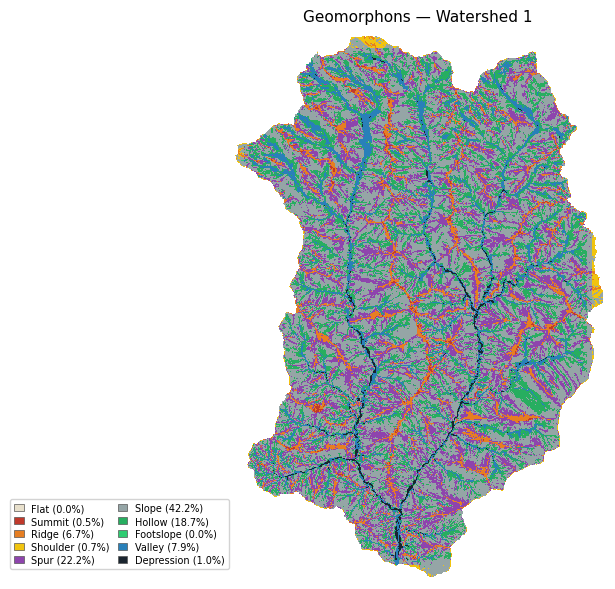

Figure saved.


In [26]:
# Geomorphons class definitions (WhiteboxTools --forms output: classes 1-10)
CLASS_LABELS = {
    1:  "Flat",
    2:  "Summit",
    3:  "Ridge",
    4:  "Shoulder",
    5:  "Spur",
    6:  "Slope",
    7:  "Hollow",
    8:  "Footslope",
    9:  "Valley",
    10: "Depression",
}
 
# Carefully chosen, perceptually distinct, terrain-appropriate colors
CLASS_COLORS = {
    1:  "#E8E0CC",   # Flat        — warm off-white
    2:  "#C0392B",   # Summit      — deep red
    3:  "#E67E22",   # Ridge       — burnt orange
    4:  "#F1C40F",   # Shoulder    — golden yellow
    5:  "#8E44AD",   # Spur        — purple
    6:  "#95A5A6",   # Slope       — cool grey
    7:  "#27AE60",   # Hollow      — forest green
    8:  "#2ECC71",   # Footslope   — light green
    9:  "#2980B9",   # Valley      — mid blue
    10: "#1A252F",   # Depression  — near black
}
 
with rasterio.open(geomorphons_output) as src:
    data = src.read(1, masked=True)
    nodata = src.nodata
    transform = src.transform
    bounds = src.bounds
 
# Mask nodata
if nodata is not None:
    data = np.ma.masked_equal(data, nodata)
data = np.ma.masked_equal(data, 0)
 
# Build colormap and norm from class colors
classes = sorted(CLASS_COLORS.keys())
cmap_colors = [CLASS_COLORS[c] for c in classes]
cmap = mcolors.ListedColormap(cmap_colors)
norm = mcolors.BoundaryNorm(boundaries=[c - 0.5 for c in classes] + [classes[-1] + 0.5], ncolors=len(classes))
 
# Compute class distribution
unique, counts = np.unique(data.compressed().astype(int), return_counts=True)
total = counts.sum()
dist = {int(u): int(c) for u, c in zip(unique, counts)}
 
fig, ax = plt.subplots(figsize=(8, 6))
 
ax.imshow(data, cmap=cmap, norm=norm, interpolation="nearest")
ax.set_title(f"Geomorphons — Watershed {point_id}", fontsize=11, pad=10)
ax.axis("off")
 
patches = [
    mpatches.Patch(facecolor=CLASS_COLORS[c], edgecolor="#555", linewidth=0.5,
                   label=f"{CLASS_LABELS[c]} ({dist.get(c,0)/total*100:.1f}%)")
    for c in classes if dist.get(c, 0) > 0
]
ax.legend(
    handles=patches,
    loc="lower right",
    bbox_to_anchor=(0.01, 0.01),
    fontsize=7,
    framealpha=0.85,
    edgecolor="#ccc",
    ncol=2,
    handlelength=1,
    labelspacing=0.3,
    columnspacing=0.8,
)
 
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, f"geomorphons_{point_id}_map.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Figure saved.")

In [27]:
print(f"\n{'Class':<12} {'Label':<12} {'Pixels':>10} {'Coverage':>10}")
print("─" * 48)
for c in classes:
    n = dist.get(c, 0)
    if n > 0:
        pct = n / total * 100
        print(f"{c:<12} {CLASS_LABELS[c]:<12} {n:>10,} {pct:>9.1f}%")
print("─" * 48)
print(f"{'TOTAL':<24} {total:>10,} {'100.0%':>10}")
 


Class        Label            Pixels   Coverage
────────────────────────────────────────────────
1            Flat                  3       0.0%
2            Summit            4,730       0.5%
3            Ridge            63,850       6.7%
4            Shoulder          6,567       0.7%
5            Spur            211,395      22.2%
6            Slope           401,080      42.2%
7            Hollow          178,118      18.7%
8            Footslope            71       0.0%
9            Valley           74,588       7.9%
10           Depression        9,700       1.0%
────────────────────────────────────────────────
TOTAL                       950,102     100.0%


In [28]:
registry_json = os.path.join(factor_output_dir, f"factor_registry_{point_id}.json")
if os.path.exists(registry_json):
    with open(registry_json, "r") as f:
        factor_files = json.load(f)
    factor_files["geomorphons"] = geomorphons_output
    with open(registry_json, "w") as f:
        json.dump(factor_files, f, indent=2)
    print(f"Registered geomorphons in factor registry: {registry_json}")
 
 
# ## Interpretation
#
# Geomorphons classify terrain into 10 standard landform types using
# line-of-sight analysis across 8 cardinal profiles:
#
# | Class | Label      | Landslide relevance                        |
# |-------|------------|--------------------------------------------|
# | 1     | Flat       | Low susceptibility                         |
# | 2     | Summit     | Source zone potential                      |
# | 3     | Ridge      | Lateral spread risk                        |
# | 4     | Shoulder   | Transition — moderate risk                 |
# | 5     | Spur       | Divergent flow — moderate risk             |
# | 6     | Slope      | Primary transport zone — high risk         |
# | 7     | Hollow     | Convergent flow — very high risk           |
# | 8     | Footslope  | Deposition zone                            |
# | 9     | Valley     | Channelized debris flow risk               |
# | 10    | Depression | Water accumulation — high saturation risk  |
 

Registered geomorphons in factor registry: results/factors/factor_registry_1.json


## Interpretation

Geomorphons classify terrain into standard landform types such as:

- ridge
- valley
- spur
- hollow
- slope
- flat

This output can be used as an input factor in landslide susceptibility mapping.